Wave height results from CFD output
Average wave height at WG1 (Incident)     = 0.023058 m
Average wave height at WG3 (Transmitted)  = 0.022080 m
Transmission coefficient, Kt = WG3/WG1    = 0.957574
Attenuation percentage                    = 4.24 %


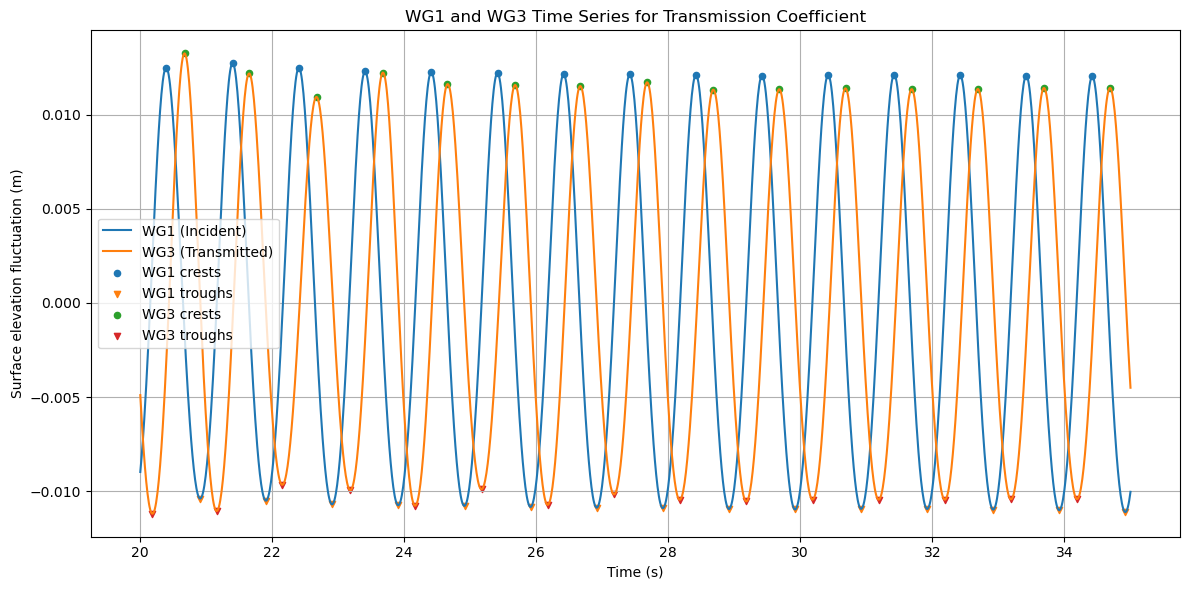

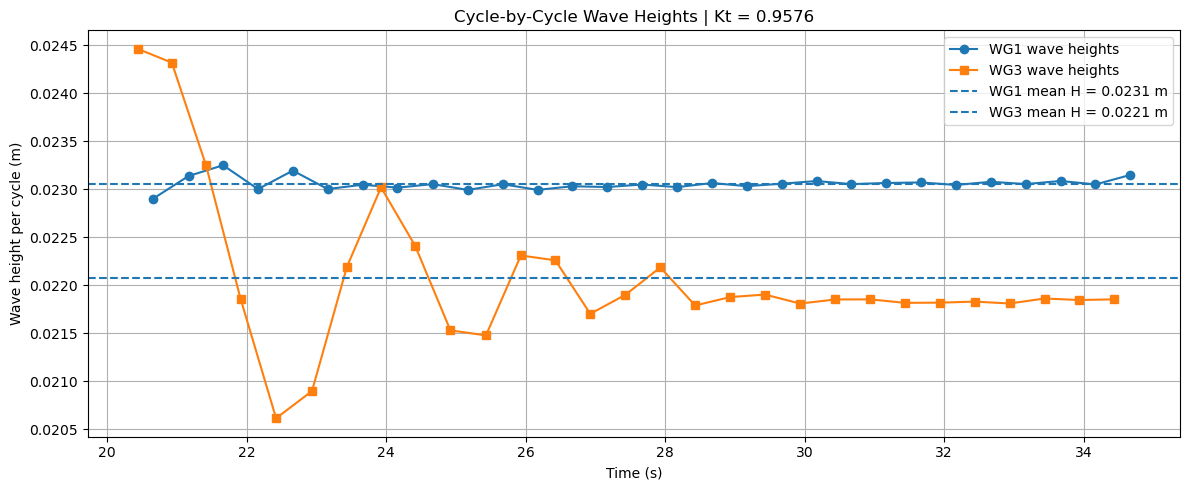

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# User settings
# =========================================================
file_path = r"D:\Phd Research\CFD and Reef\WAVE_GAUGE_Flume_with_Reef_v2.xlsx"

time_col = "TIME"
wg1_col = "WAVE GAGE 1"   # Incident wave
wg3_col = "WAVE GAGE 3"   # Transmitted wave

# If CFD output is absolute water level, subtract still water depth
still_water_level = 0.3

# Steady-state analysis window
t_min = 20.0
t_max = 35.0

# Minimum time gap between crests/troughs (sec)
# For T ~ 1 s, 0.4-0.6 s is usually reasonable
min_peak_distance_sec = 0.4

# =========================================================
# Helper functions
# =========================================================
def find_local_extrema(time, eta, min_distance_sec=0.4):
    """
    Find local maxima and minima using simple neighbor comparison
    and enforce a minimum time distance between accepted extrema.
    """
    time = np.asarray(time)
    eta = np.asarray(eta)

    dt = np.median(np.diff(time))
    min_samples = max(1, int(min_distance_sec / dt))

    max_idx = []
    min_idx = []

    # Raw local extrema
    for i in range(1, len(eta) - 1):
        if eta[i] > eta[i - 1] and eta[i] > eta[i + 1]:
            max_idx.append(i)
        if eta[i] < eta[i - 1] and eta[i] < eta[i + 1]:
            min_idx.append(i)

    # Enforce spacing
    def filter_by_distance(indices, values, choose="max"):
        if not indices:
            return []

        kept = [indices[0]]
        for idx in indices[1:]:
            if idx - kept[-1] >= min_samples:
                kept.append(idx)
            else:
                # Keep stronger extremum within the forbidden window
                prev = kept[-1]
                if choose == "max" and values[idx] > values[prev]:
                    kept[-1] = idx
                elif choose == "min" and values[idx] < values[prev]:
                    kept[-1] = idx
        return kept

    max_idx = filter_by_distance(max_idx, eta, choose="max")
    min_idx = filter_by_distance(min_idx, eta, choose="min")

    return np.array(max_idx), np.array(min_idx)


def compute_wave_heights_by_cycles(time, eta, min_distance_sec=0.4):
    """
    Compute wave heights using crest-to-following-trough or trough-to-following-crest.
    Returns average wave height and details.
    """
    max_idx, min_idx = find_local_extrema(time, eta, min_distance_sec=min_distance_sec)

    extrema = []
    for i in max_idx:
        extrema.append((i, "max", eta[i], time[i]))
    for i in min_idx:
        extrema.append((i, "min", eta[i], time[i]))

    extrema.sort(key=lambda x: x[0])

    wave_heights = []
    wave_times = []

    for i in range(len(extrema) - 1):
        idx1, type1, val1, t1 = extrema[i]
        idx2, type2, val2, t2 = extrema[i + 1]

        if type1 != type2:
            H = abs(val1 - val2)
            wave_heights.append(H)
            wave_times.append(0.5 * (t1 + t2))

    wave_heights = np.array(wave_heights)
    wave_times = np.array(wave_times)

    if len(wave_heights) == 0:
        return np.nan, wave_heights, wave_times, max_idx, min_idx

    return np.mean(wave_heights), wave_heights, wave_times, max_idx, min_idx


# =========================================================
# Read data
# =========================================================
df = pd.read_excel(file_path)

df = df[[time_col, wg1_col, wg3_col]].copy()
df.columns = ["Time", "WG1", "WG3"]

df["Time"] = pd.to_numeric(df["Time"], errors="coerce")
df["WG1"] = pd.to_numeric(df["WG1"], errors="coerce")
df["WG3"] = pd.to_numeric(df["WG3"], errors="coerce")

df = df.dropna().sort_values("Time").reset_index(drop=True)

# =========================================================
# Convert absolute level to surface fluctuation
# =========================================================
df["WG1"] = df["WG1"] - still_water_level
df["WG3"] = df["WG3"] - still_water_level

# =========================================================
# Select steady-state window
# =========================================================
df = df[(df["Time"] >= t_min) & (df["Time"] <= t_max)].copy().reset_index(drop=True)

time = df["Time"].values
wg1 = df["WG1"].values
wg3 = df["WG3"].values

# Optional: remove mean in selected window
wg1 = wg1 - np.mean(wg1)
wg3 = wg3 - np.mean(wg3)

# =========================================================
# Compute wave heights
# =========================================================
H_wg1, Hs_wg1, Ht_wg1, max1, min1 = compute_wave_heights_by_cycles(
    time, wg1, min_distance_sec=min_peak_distance_sec
)

H_wg3, Hs_wg3, Ht_wg3, max3, min3 = compute_wave_heights_by_cycles(
    time, wg3, min_distance_sec=min_peak_distance_sec
)

# =========================================================
# Transmission coefficient
# =========================================================
Kt = H_wg3 / H_wg1 if H_wg1 and not np.isnan(H_wg1) else np.nan
attenuation_pct = (1 - Kt) * 100 if not np.isnan(Kt) else np.nan

# =========================================================
# Print results
# =========================================================
print("====================================")
print("Wave height results from CFD output")
print("====================================")
print(f"Average wave height at WG1 (Incident)     = {H_wg1:.6f} m")
print(f"Average wave height at WG3 (Transmitted)  = {H_wg3:.6f} m")
print(f"Transmission coefficient, Kt = WG3/WG1    = {Kt:.6f}")
print(f"Attenuation percentage                    = {attenuation_pct:.2f} %")
print("====================================")

# =========================================================
# Plot time series + extrema
# =========================================================
plt.figure(figsize=(12, 6))
plt.plot(time, wg1, label="WG1 (Incident)", linewidth=1.5)
plt.plot(time, wg3, label="WG3 (Transmitted)", linewidth=1.5)

plt.scatter(time[max1], wg1[max1], s=20, marker="o", label="WG1 crests")
plt.scatter(time[min1], wg1[min1], s=20, marker="v", label="WG1 troughs")
plt.scatter(time[max3], wg3[max3], s=20, marker="o", label="WG3 crests")
plt.scatter(time[min3], wg3[min3], s=20, marker="v", label="WG3 troughs")

plt.xlabel("Time (s)")
plt.ylabel("Surface elevation fluctuation (m)")
plt.title("WG1 and WG3 Time Series for Transmission Coefficient")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# Plot cycle-by-cycle wave heights
# =========================================================
plt.figure(figsize=(12, 5))
plt.plot(Ht_wg1, Hs_wg1, marker="o", label="WG1 wave heights")
plt.plot(Ht_wg3, Hs_wg3, marker="s", label="WG3 wave heights")
plt.axhline(H_wg1, linestyle="--", label=f"WG1 mean H = {H_wg1:.4f} m")
plt.axhline(H_wg3, linestyle="--", label=f"WG3 mean H = {H_wg3:.4f} m")

plt.xlabel("Time (s)")
plt.ylabel("Wave height per cycle (m)")
plt.title(f"Cycle-by-Cycle Wave Heights | Kt = {Kt:.4f}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()